# Do last week's winning coins keep winning? 🪙
### Crypto momentum — the one factor academia says crypto really has, tested in plain sight

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Survives the 2022 bear?: Busted](https://img.shields.io/badge/Survives_the_2022_bear%3F-Busted-8b949e?style=flat-square)

Every crypto Twitter thread has a version of it: *ride the hot coin*. Academia, for once, agrees — a famous *Journal of Finance* study (Liu, Tsyvinski & Wu, 2022) sifted the whole crypto factor zoo and found that almost nothing predicts coin returns... **except momentum**: the coins that beat the pack last week tend to beat it again next week.

So we rebuilt it, the honest way: ~44 top coins from 2017 to 2026, **including the corpses** — LUNA with its −100% death week, FTX's token with its −93% week, Monero after Binance kicked it off — rank them every Sunday night on last week's return, buy the top fifth, short the bottom fifth, hold one week, repeat.

> 📓 **Plain-language layer.** Want the *t*-stats, turnover math and placebo tests? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Even with 11 delisted/dead pairs in the panel, the 33 *live* names are coins that are still big in 2026 — a **survivorship** tilt we name rather than hide. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from crypto_xs_momentum import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real()
    RES = st.run_xs_momentum(PANEL, k=1)          # headline: 1-week formation
else:
    PANEL = RES = None
print("real panel cached:", HAVE_REAL,
      "| shape:", (None if PANEL is None else PANEL.shape),
      "| holding weeks:", (0 if RES is None else len(RES)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2017-01-02', 'end_open': '2026-06-22', 'asof': '2026-06-28', 'years': 9.5, 'weeks': 495, 'coins': 44, 'n_delisted': 11, 'avg_n': 34.9, 'live_from': '2017-11-20', 'fingerprint': 'df8a5231ba1d', 'headline': [(1, 449, 164.1, 133.8, 3.56, 1.12, 55.0, 113.2, 3.3), (2, 448, 135.4, 101.8, 1.88, 0.66, 53.8, 114.0, 2.22), (3, 447, 197.8, 177.8, 2.95, 0.99, 55.5, 136.0, 2.63), (4, 446, 121.6, 87.9, 2.61, 0.83, 54.3, 76.8, 2.51)], 'mkt_bps': 148.0, 'mkt_t': 1.9, 'win_bps': 261.2, 'win_t': 2.6, 'subs': [('2017-2019', 111, 194.6, 173.4, 1.62, 55.9), ('2020-2021', 104, 371.6, 571.0, 3.8, 63.5), ('2022', 52, 10.5, 5.6, 0.13, 48.1), ('2023-2026', 182, 70.8, 44.5, 1.3, 51.6)], 'bull': (243, 255.8, 3.51, 1.47), 'bear': (206, 56.0, 1.13, 0.55), 'welch_diff': 2.09, 'to_win': 1.48, 'to_lose': 1.6, 'borrow_ann': 10.0, 'costs': [(10, 114.1, 80.7, 2.47, 98.4, 2.86), (25, 67.8, 42.3, 1.46, 76.1, 2.21), (50, -9.3, -4.7, -0.2, 39.0, 1.13)], 'placebo': {'seeds': 20, 'mean_bps': 7.2, 'std_bps': 36.4, 'mean_t': 0.2}, 'syn': [(0.0, -39.2, -1.09), (0.1, 396.7, 11.14)]}


real panel cached: True | shape: (495, 44) | holding weeks: 449


## The answer first

| Question | Answer |
|---|---|
| Do last week's winners keep winning? | **Yes — really.** Winners beat losers by about **+1.6% per week** over 9 years (HAC *t* = 3.56) — a genuine signal, not luck. |
| Can you trade it? | **Barely.** The portfolio replaces ~150% of itself *every week*. At big-pair fees it survives; at alt-coin slippage it dies. |
| Did it survive the 2022 bear? | **No.** Through LUNA and FTX it made **+10 bps/week ≈ nothing** (*t* = 0.13). It's a bull-market factor. |

The rest of this notebook shows you exactly where those three answers come from.

## 1 · The race: winners, losers, and the market

Each Sunday close we rank every eligible coin on its **past 1-week return**, then hold the top fifth (*winners*) and bottom fifth (*losers*) for the **next** week — decisions are made strictly before the money is at risk. Here is the cumulative ride (log scale — crypto numbers are absurd).

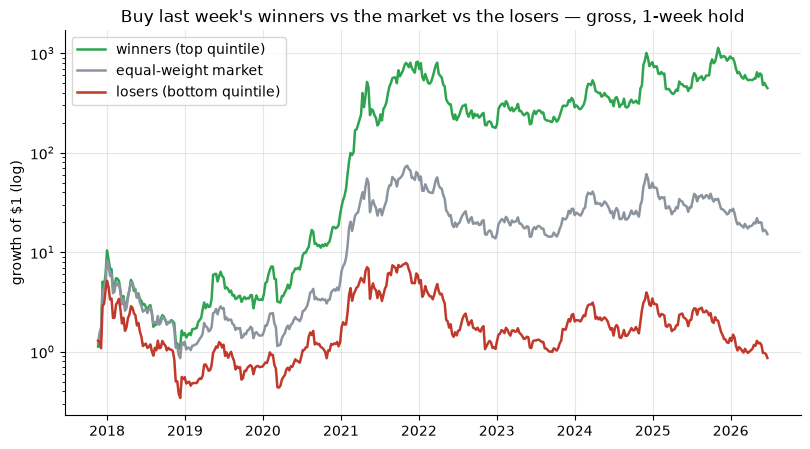

winners leg +261 bps/wk | market +148 | spread +164 bps/wk (HAC t=3.56)


In [2]:
if HAVE_REAL:
    fig, ax = plt.subplots()
    for col, c, lab in [('win', GREEN, 'winners (top quintile)'),
                        ('mkt', GREY, 'equal-weight market'),
                        ('lose', RED, 'losers (bottom quintile)')]:
        ax.plot(RES.index, (1 + RES[col]).cumprod(), color=c, lw=1.8, label=lab)
    ax.set_yscale('log')
    ax.set_title('Buy last week\'s winners vs the market vs the losers — gross, 1-week hold')
    ax.set_ylabel('growth of $1 (log)')
    ax.legend()
    plt.show()
    print(f"winners leg {R['win_bps']:+.0f} bps/wk | market {R['mkt_bps']:+.0f} | "
          f"spread {R['headline'][0][2]:+.0f} bps/wk (HAC t={R['headline'][0][4]})")
else:
    print('cache missing — the frozen numbers in R tell the story:', R['headline'][0])

The green line is the whole claim: last week's winners **keep pulling away** from the pack, and the losers keep sinking. The gap — about **+1.6% per week** before costs — is the momentum premium.

> 🔬 **For the quants.** Newey-West *t* = 3.56 on the weekly spread, 449 weeks, one-week execution lag, quintiles of ~7 coins from an average cross-section of ~35.

## 2 · When did it pay? Year by year

A factor that only works in one regime is a weather vane, not a law. Let's see the same spread carved into calendar years.

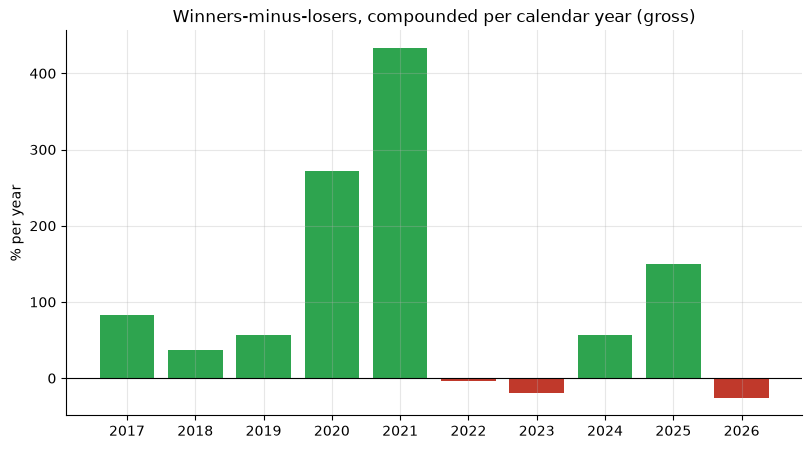

week
2017     82.6
2018     37.4
2019     56.8
2020    272.1
2021    433.4
2022     -3.9
2023    -20.1
2024     56.5
2025    149.8
2026    -25.9


In [3]:
if HAVE_REAL:
    yearly = RES['wml'].groupby(RES.index.year).apply(lambda x: (1 + x).prod() - 1) * 100
    colors = [GREEN if v > 0 else RED for v in yearly]
    fig, ax = plt.subplots()
    ax.bar(yearly.index.astype(str), yearly, color=colors)
    ax.axhline(0, color='k', lw=.8)
    ax.set_title('Winners-minus-losers, compounded per calendar year (gross)')
    ax.set_ylabel('% per year')
    plt.show()
    print(yearly.round(1).to_string())
else:
    print('sub-period stats (frozen):', R['subs'])

The pattern is loud: momentum feasted in the **2020–2021 bull** (+372 bps/week, *t* = 3.8), then went **silent in 2022** — the year of LUNA and FTX — earning +10 bps/week, statistically zero. Since 2023 it's positive but soft (+71 bps/week, *t* = 1.3: below the certification bar on its own).

**And no — it did not survive the 2022 bear.** That's the grey badge at the top. The one factor crypto "really has" clocks out exactly when you'd want a factor to show up.

## 3 · The catch: this thing *churns*

"Buy last week's winners" sounds lazy. It isn't — last week's winners are rarely *this* week's winners, so the portfolio replaces roughly **150% of itself every week**, per leg. Every one of those trades pays a fee and crosses a spread.

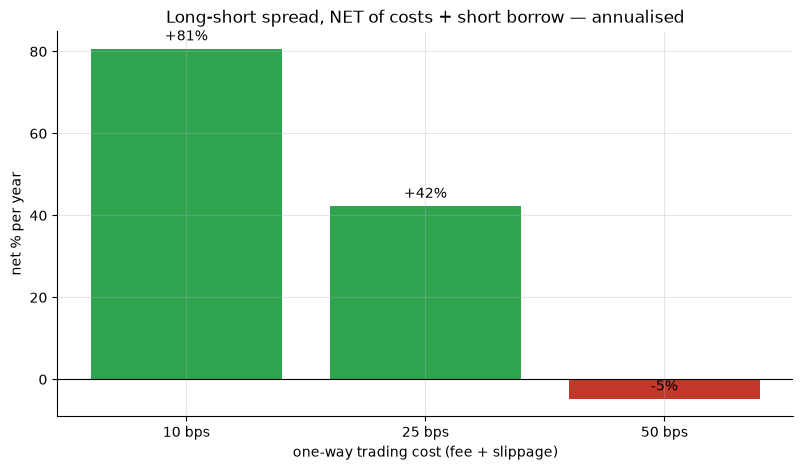

turnover ~1.5x NAV/week per leg; shorts pay 10%/yr borrow


In [4]:
cost_labels = [f'{c[0]} bps' for c in R['costs']]
net_ann = [c[2] for c in R['costs']]
colors = [GREEN if v > 20 else (AMBER if v > 0 else RED) for v in net_ann]
fig, ax = plt.subplots()
ax.bar(cost_labels, net_ann, color=colors)
ax.axhline(0, color='k', lw=.8)
ax.set_title('Long-short spread, NET of costs + short borrow — annualised')
ax.set_xlabel('one-way trading cost (fee + slippage)')
ax.set_ylabel('net % per year')
for x, v in zip(cost_labels, net_ann):
    ax.text(x, v + 2, f'{v:+.0f}%', ha='center')
plt.show()
print('turnover ~%.1fx NAV/week per leg; shorts pay %.0f%%/yr borrow'
      % (R['to_win'], R['borrow_ann']))

At **10 bps** one-way (BTC/ETH-grade taker fees) the edge survives handsomely. At **25 bps** (realistic all-in cost on liquid alts) it's amber — positive but no longer provable. At **50 bps** (thin alts, 2018-era spreads) it's gone. A gentler vehicle — just **tilting a long-only basket toward recent winners**, no shorting — holds up better: it beats the market by ~+76 bps/week even at 25 bps (*t* = 2.21).

## The verdict

**Real. Fragile. Bear-market myth busted.** Crypto cross-sectional momentum is one of the rare folk beliefs the tape actually certifies — +1.6%/week gross, *t* = 3.56, with the corpses in the panel. But it's a **bull-market, big-pair, high-churn** edge: costs above ~25 bps eat the long-short, the post-2022 sample can't certify itself alone, and in the one year you truly needed it, it paid nothing.

*Numbers: [docs/results.md](../docs/results.md) · rigor: [02_for_the_quants.ipynb](02_for_the_quants.ipynb) · not investment advice.*